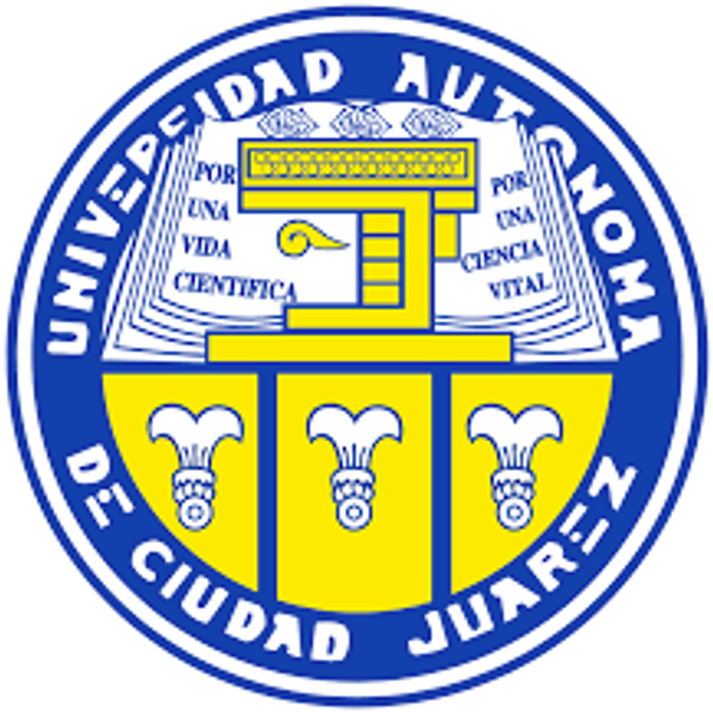


## Tarea 8: Etiquetado gramatical
## Nombre: Sergio Trejo
## Matricula: 261539
## Materia: Procesamiento de Lenguaje Natural_A_Presencial_260206

**Aplique los conceptos de etiquetado gramatical vistos en clase mediante el análisis de un texto en español, y realizar un análisis exploratorio de datos sencillo a partir de las etiquetas obtenidas. El texto para analizar se presenta a continuación:**

**Instrucciones:**

1.	Divida el texto en tokens.
2.	Asigne a cada token su etiqueta gramatical correspondiente utilizando alguno de los ejemplos de la presentación del tema que está en el campus virtual.

3.	Realice un análisis exploratorio de datos con la información obtenida donde muestre:
a.	 el número total de tokens
b.	número de tokens distintos
c.	conteo de cada categoría gramatical en una gráfica de barras
d.	los cinco tokens más frecuentes del texto con sus respectivas etiquetas gramaticales en una gráfica de barras
e.	las tres clases gramaticales más frecuentes del texto en una gráfica de barras

4.	Redacte una conclusión sobre el texto y su etiquetado gramatical.


In [1]:
#Librerias
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
#Cargar el modelo de lenguaje
nlp = spacy.load("es_core_news_sm")

#Texto de ejemplo
texto = """
En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. 
Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. 
Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. 
En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. 
Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. 
Por esta razón, el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.
"""

In [5]:
#Dividir el texto en tokens
doc = nlp(texto)

#2.	Asigne a cada token su etiqueta gramatical correspondiente utilizando alguno de los ejemplos de la presentación del tema que está en el campus virtual.
print(f"{'Token':<15}{'POS':<10}{'FEATS':<30}{'DEPREL':<10}")
print("-" * 70)

tokens = []
pos_tags = []

for token in doc:

    feats = str(token.morph)

    print(f"{token.text:<15}{token.pos_:<10}{feats:<30}{token.dep_:<10}")

    # Guardar tokens para el analisis exploratorio
    if not token.is_punct and not token.is_space:
        tokens.append(token.text.lower())
        pos_tags.append(token.pos_)



Token          POS       FEATS                         DEPREL    
----------------------------------------------------------------------

              SPACE                                   dep       
En             ADP                                     case      
los            DET       Definite=Def|Gender=Masc|Number=Plur|PronType=Artdet       
últimos        ADJ       Gender=Masc|NumType=Ord|Number=Pluramod      
años           NOUN      Gender=Masc|Number=Plur       obl       
,              PUNCT     PunctType=Comm                punct     
muchas         DET       Gender=Fem|NumType=Card|Number=Plur|PronType=Inddet       
universidades  NOUN      Gender=Fem|Number=Plur        nsubj     
han            AUX       Mood=Ind|Number=Plur|Person=3|Tense=Pres|VerbForm=Finaux       
incorporado    VERB      Gender=Masc|Number=Sing|Tense=Past|VerbForm=PartROOT      
herramientas   NOUN      Gender=Fem|Number=Plur        obj       
digitales      ADJ       Number=Plur                  


Número total de tokens: 111
Número de tokens distintos: 88

Conteo de cada categoría gramatical:
Counter({'NOUN': 34, 'ADP': 18, 'DET': 16, 'VERB': 13, 'ADJ': 12, 'ADV': 7, 'CCONJ': 5, 'AUX': 3, 'SCONJ': 2, 'PRON': 1})


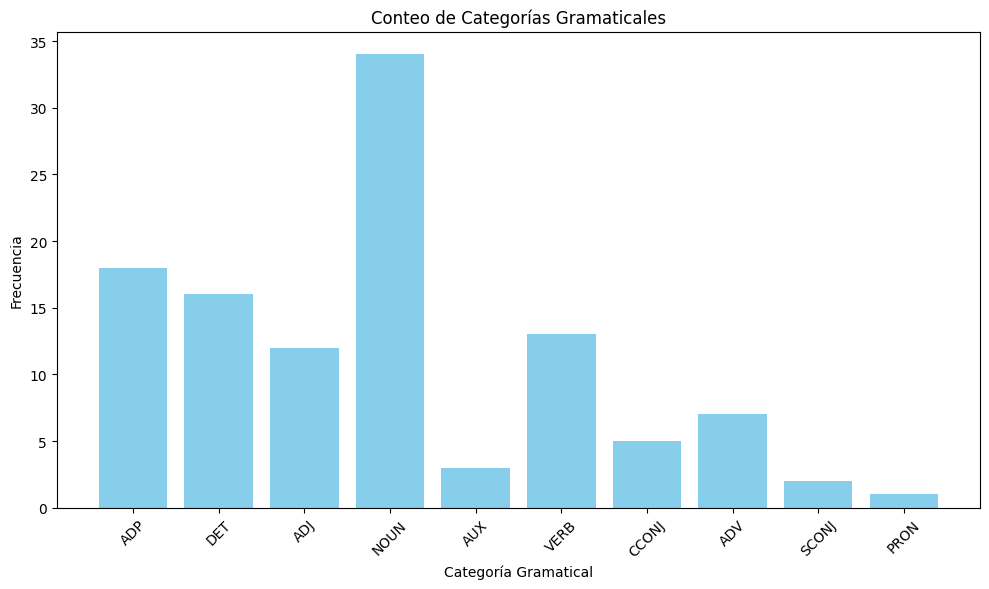

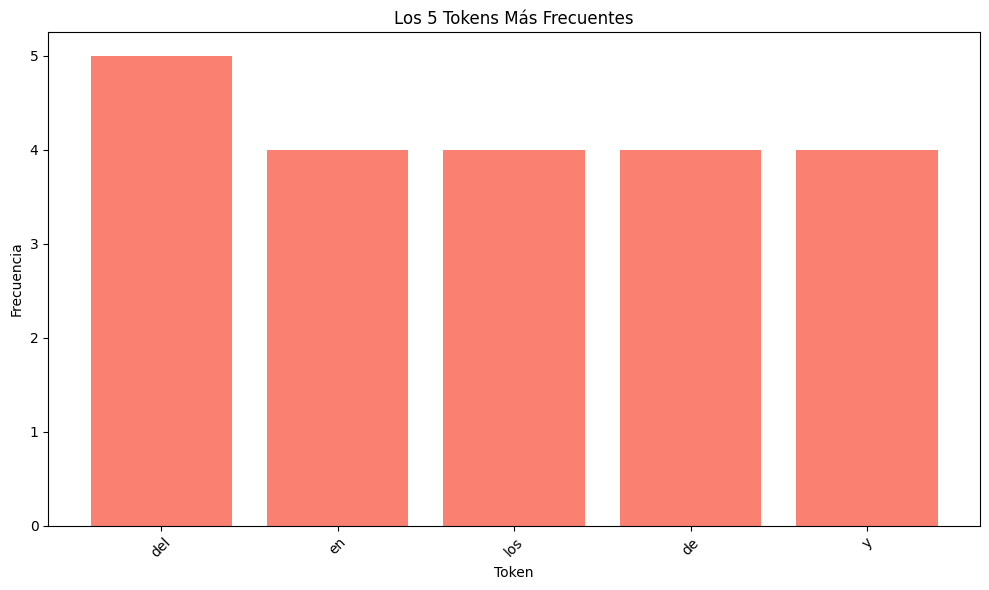

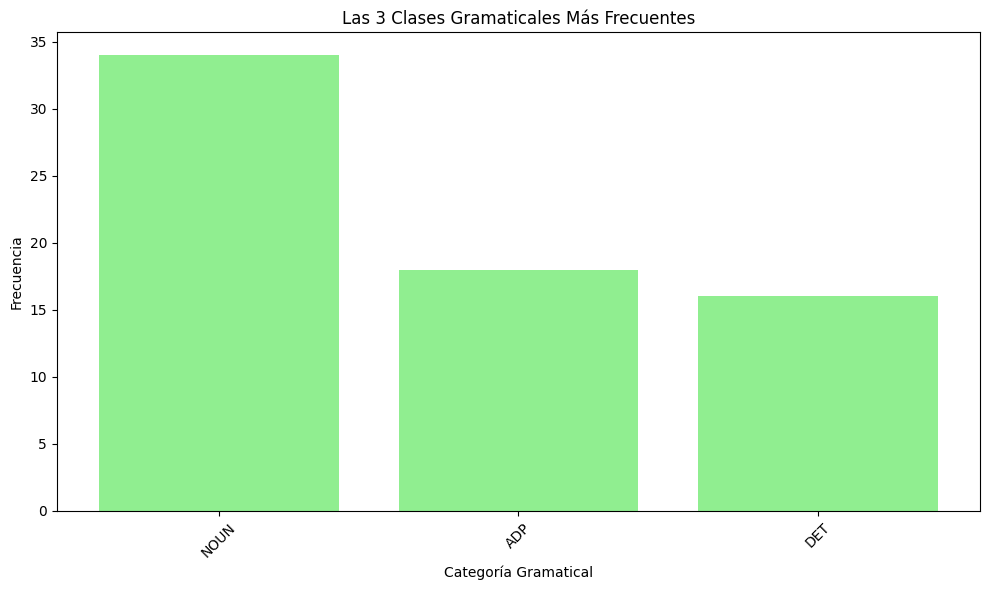

In [7]:
# Realice un análisis exploratorio de datos con la información obtenida
#El numero de tokens
total_tokens = len(tokens)
print(f"\nNúmero total de tokens: {total_tokens}")

#número de tokens distintos
tokens_unicos = len(set(tokens))
print(f"Número de tokens distintos: {tokens_unicos}")

#conteo de cada categoría gramatical en una gráfica de barras
conteo_pos = Counter(pos_tags)
print("\nConteo de cada categoría gramatical:")
print(conteo_pos)
# Graficar el conteo de cada categoría gramatical
plt.figure(figsize=(10, 6))
plt.bar(conteo_pos.keys(), conteo_pos.values(), color='skyblue')
plt.title('Conteo de Categorías Gramaticales')
plt.xlabel('Categoría Gramatical')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Los cinco tokens más frecuentes del texto con sus respectivas etiquetas gramaticales en una gráfica de barras.
conteo_tokens = Counter(tokens)
top5 = conteo_tokens.most_common(5)

palabras = [x[0] for x in top5]
frecuencias = [x[1] for x in top5]

#graficar los cinco tokens más frecuentes
plt.figure(figsize=(10, 6))
plt.bar(palabras, frecuencias, color='salmon')
plt.title('Los 5 Tokens Más Frecuentes')
plt.xlabel('Token')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Las tres clases gramaticales más frecuentes del texto en una gráfica de barras
top3 = conteo_pos.most_common(3)
categorias = [x[0] for x in top3]
frecuencias = [x[1] for x in top3]
#graficar las tres clases gramaticales más frecuentes
plt.figure(figsize=(10, 6))
plt.bar(categorias, frecuencias, color='lightgreen')
plt.title('Las 3 Clases Gramaticales Más Frecuentes')
plt.xlabel('Categoría Gramatical')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





## Conclusion Sobre el Texto y su Etiquetado Gramatical

* El etiquetado gramatical permitio identificar la funcion de cada palabra del texto, como sustantivos, verbos y adjetivos. Esto nos ayuda a entender mejor la estructura del lenguaje usado en el texto. 
* Durante la identificacion de los tokens Top 5, los mas frecuentes son palabras comunes como "de","en","los" y "y". Estas stopwords no se removieron del analisis y por eso aparecen con mayor frecuencia. Este tipo de palabras cumple una funcion gramatical dentro del texto, aunque no representan directamente el contenido principal del corpus analizado.
* El analisis exploratorio del texto que se analizo, mostro que los sutantivos y verbos aparecen con mayor frecuencia, lo cual es comun en textos como este que son informativos que presentan conceptos e ideas, como tambien acciones relacionadas con la educacion moderna y tecnologia. 
* Este tipo de analisis exploratorio demuestra como el texto se puede categorizar por sus caracteristicas de lenguaje en base a sus etiquetados gramaticales y facilita la visualizacion de patrones. 